In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
rfm=pd.read_csv("C:\\Users\\jahnavi\\OneDrive\\Desktop\\New folder (2)\\rfm_final.csv")
df=pd.read_csv("C:\\Users\\jahnavi\\OneDrive\\Desktop\\New folder (2)\\sample superstore dataset.csv",encoding='latin-1')
df['Order Date']=pd.to_datetime(df['Order Date'],format='mixed',dayfirst=False)

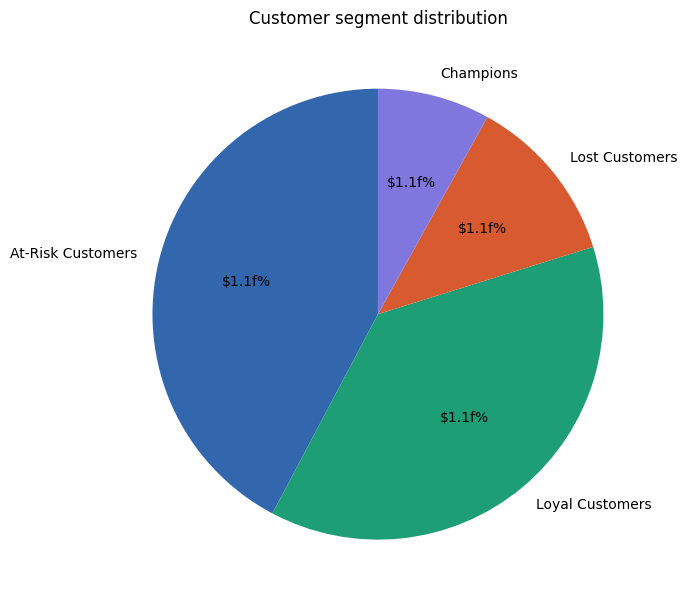

In [24]:
plt.figure(figsize=(7,7))
colors=['#3266ad','#1D9E75','#D85A30','#7F77DD']
rfm['Segment'].value_counts().plot(kind='pie',autopct='$1.1f%%',
                                   colors=colors,startangle=90)
plt.title('Customer segment distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('segment_distribution.png')
plt.show()

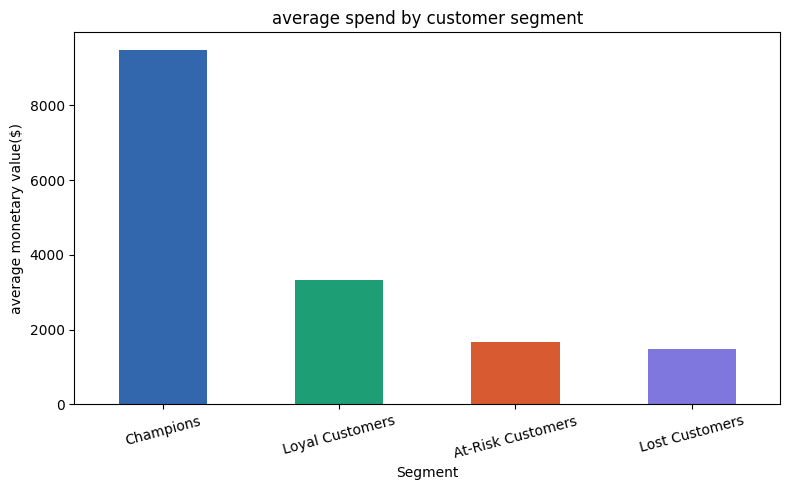

In [26]:
plt.figure(figsize=(8,5))
seg_monetary=rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=False)
seg_monetary.plot(kind='bar',color=colors)
plt.title('average spend by customer segment')
plt.xlabel('Segment')
plt.ylabel('average monetary value($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('segment_monetary.png')
plt.show()

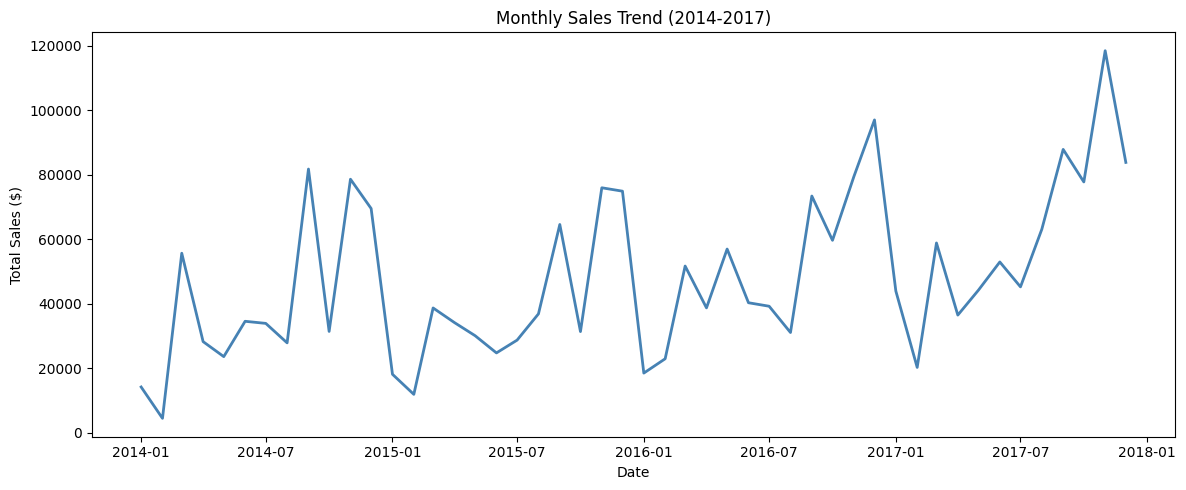

In [27]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
monthly = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Order Year','Order Month']].assign(day=1).rename(
    columns={'Order Year':'year','Order Month':'month'}))
plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend (2014-2017)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()



<Figure size 800x500 with 0 Axes>

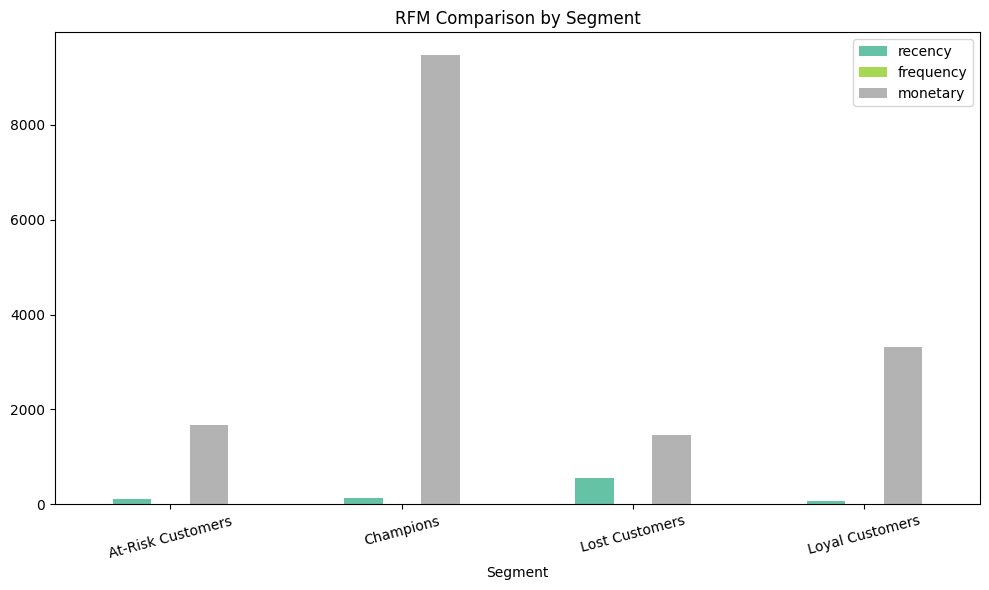

All visualizations saved!


In [29]:
plt.figure(figsize=(8,5))
seg_rfm = rfm.groupby('Segment')[['recency','frequency','monetary']].mean().reset_index()
seg_rfm.set_index('Segment')[['recency','frequency','monetary']].plot(
    kind='bar', figsize=(10,6), colormap='Set2')
plt.title('RFM Comparison by Segment')
plt.xlabel('Segment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('rfm_comparison.png')
plt.show()
print("All visualizations saved!")